
**Project Overview**

The objective of this project is to build a machine learning model that can predict the Manufacturer's Suggested Retail Price (MSRP) of a car based on its specifications.

The dataset contains information about different cars, including their brand, model, year, engine details, transmission, drivetrain, mileage, vehicle type, and popularity.

Since MSRP is a continuous numerical value, this project is treated as a regression problem.

The project will cover the complete machine learning workflow, starting from data cleaning and exploratory data analysis and ending with model building, evaluation, and deployment.

**Import Required Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [13]:
df = pd.read_csv("car_MSRP.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (11914, 16)


**View the First Few Records**

In [14]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


**Check Dataset Information**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Make                                          11914 non-null  object 
 1   Model                                         11914 non-null  object 
 2   Year                                          11914 non-null  int64  
 3   Engine Fuel Type                              11911 non-null  object 
 4   Engine HP                                     11845 non-null  float64
 5   Engine Cylinders                              11884 non-null  float64
 6   Transmission Type                             11914 non-null  object 
 7   Driven_Wheels                                 11914 non-null  object 
 8   Number of Doors                               11908 non-null  float64
 9   Market Category                               8172 non-null  

**Check Missing Values**

In [16]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


**Check Duplicate Records**

In [17]:
df.duplicated().sum()


np.int64(715)

**Remove Duplicate Records**

In [18]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (11199, 16)


**Numerical and Categorical Columns**

In [19]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns)

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns)

Numerical columns:
Index(['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'highway MPG', 'city mpg', 'Popularity',
       'MSRP (Manufacturer's suggested retail Price)'],
      dtype='object')

Categorical columns:
Index(['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
       'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style'],
      dtype='object')


**Numerical Summary**

In [20]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP (Manufacturer's suggested retail Price)
count,11199.000000,11130.000000,11169.000000,11193.000000,11199.000000,11199.000000,11199.000000,1.119900e+04
mean,2010.714528,253.388859,5.665950,3.454123,26.610590,19.731851,1558.483347,4.192593e+04
std,7.228211,110.150938,1.797021,0.872946,8.977641,9.177555,1445.668872,6.153505e+04
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.159950e+04
50%,2015.000000,239.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.067500e+04
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.303250e+04
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


**MSRP Distribution — KDE Plot**

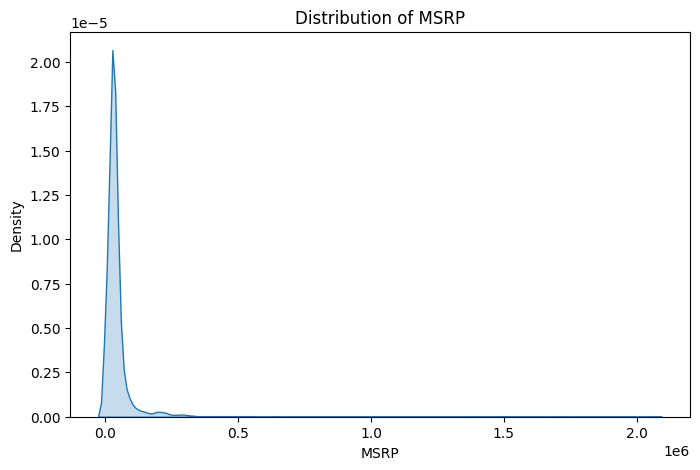

In [21]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["MSRP (Manufacturer's suggested retail Price)"], fill=True)

plt.xlabel("MSRP")
plt.ylabel("Density")
plt.title("Distribution of MSRP")

plt.show()

**MSRP Box Plot**

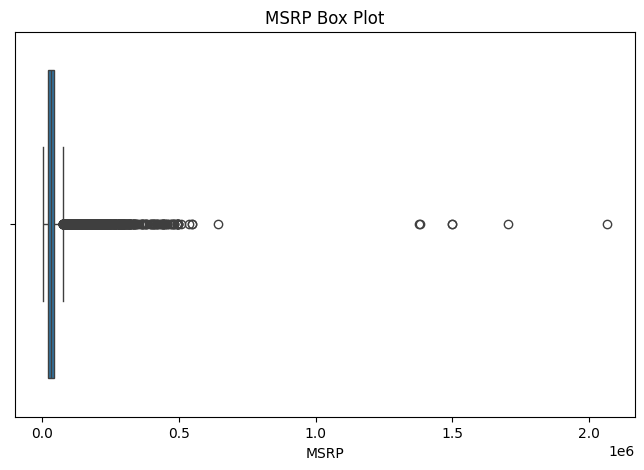

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["MSRP (Manufacturer's suggested retail Price)"])

plt.xlabel("MSRP")
plt.title("MSRP Box Plot")

plt.show()

**Investigating High-Price Cars**

In [23]:
df.nlargest(10, "MSRP (Manufacturer's suggested retail Price)")[
    ["Make", "Model", "Year", "Engine HP",
     "Engine Cylinders", "MSRP (Manufacturer's suggested retail Price)"]
]

,Make,Model,Year,Engine HP,Engine Cylinders,MSRP (Manufacturer's suggested retail Price)
11362,Bugatti,Veyron 16.4,2008,1001.0,16.0,2065902
11364,Bugatti,Veyron 16.4,2009,1001.0,16.0,1705769
8486,Lamborghini,Reventon,2008,650.0,12.0,1500000
11363,Bugatti,Veyron 16.4,2008,1001.0,16.0,1500000
6351,Maybach,Landaulet,2012,620.0,12.0,1382750
6350,Maybach,Landaulet,2011,620.0,12.0,1380000
4024,Ferrari,Enzo,2003,660.0,12.0,643330
1622,Lamborghini,Aventador,2014,720.0,12.0,548800
1626,Lamborghini,Aventador,2015,720.0,12.0,548800
1629,Lamborghini,Aventador,2016,750.0,12.0,535500


**Handle Numerical Missing Values**

In [24]:
print("Engine HP median:", df["Engine HP"].median())
print("Engine Cylinders median:", df["Engine Cylinders"].median())
print("Number of Doors median:", df["Number of Doors"].median())


Engine HP median: 239.0
Engine Cylinders median: 6.0
Number of Doors median: 4.0


**Fill Numerical Missing Values**

In [25]:
df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())
df["Number of Doors"] = df["Number of Doors"].fillna(df["Number of Doors"].median())

print("Missing numerical values filled successfully.")


Missing numerical values filled successfully.


**Verify Numerical Missing Values**

In [26]:
df[["Engine HP", "Engine Cylinders", "Number of Doors"]].isnull().sum()


,0
Engine HP,0
Engine Cylinders,0
Number of Doors,0


**Analyze Categorical Missing Values**

In [27]:
print("Engine Fuel Type:")
print(df["Engine Fuel Type"].value_counts())

print("\nMarket Category:")
print(df["Market Category"].value_counts())

Engine Fuel Type:
Engine Fuel Type
regular unleaded                                6658
premium unleaded (required)                     1956
premium unleaded (recommended)                  1392
flex-fuel (unleaded/E85)                         887
diesel                                           150
electric                                          66
flex-fuel (premium unleaded required/E85)         53
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
natural gas                                        2
Name: count, dtype: int64

Market Category:
Market Category
Crossover                                          1075
Flex Fuel                                           855
Luxury                                              819
Luxury,Performance                                  659
Hatchback                                           574
                                                   ... 
Crossover,Exotic,Luxury,High-Performanc

**Handle Categorical Missing Values**

In [28]:
df["Engine Fuel Type"] = df["Engine Fuel Type"].fillna(
    df["Engine Fuel Type"].mode()[0]
)

df["Market Category"] = df["Market Category"].fillna("Unknown")

print("Categorical missing values filled successfully.")


Categorical missing values filled successfully.


**Final Missing Value Check**

In [29]:
df.isnull().sum().sum()


np.int64(0)

**Analyze Car Manufacturers**

In [30]:
df["Make"].value_counts().head(15)


,count
Make,
Chevrolet,1083
Ford,825
Toyota,719
Volkswagen,568
Nissan,551
Dodge,529
GMC,482
Honda,433
Mazda,412


**Visualize Top Manufacturers**

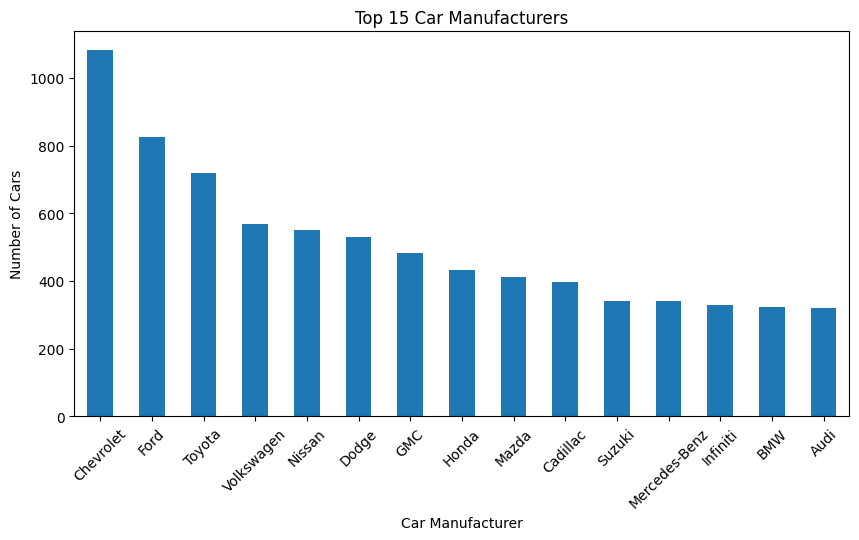

In [31]:
plt.figure(figsize=(10,5))

df["Make"].value_counts().head(15).plot(kind="bar")

plt.xlabel("Car Manufacturer")
plt.ylabel("Number of Cars")
plt.title("Top 15 Car Manufacturers")

plt.xticks(rotation=45)

plt.show()


**Analyze Car Models**

In [32]:
print("Number of unique models:", df["Model"].nunique())

Number of unique models: 915


**Top Car Models**

In [33]:
df["Model"].value_counts().head(15)

,count
Model,
Silverado 1500,156
Tundra,129
F-150,126
Sierra 1500,90
Frontier,76
Accord,74
Tacoma,71
Civic,66
Ram Pickup 1500,62


**Visualize Top Models**

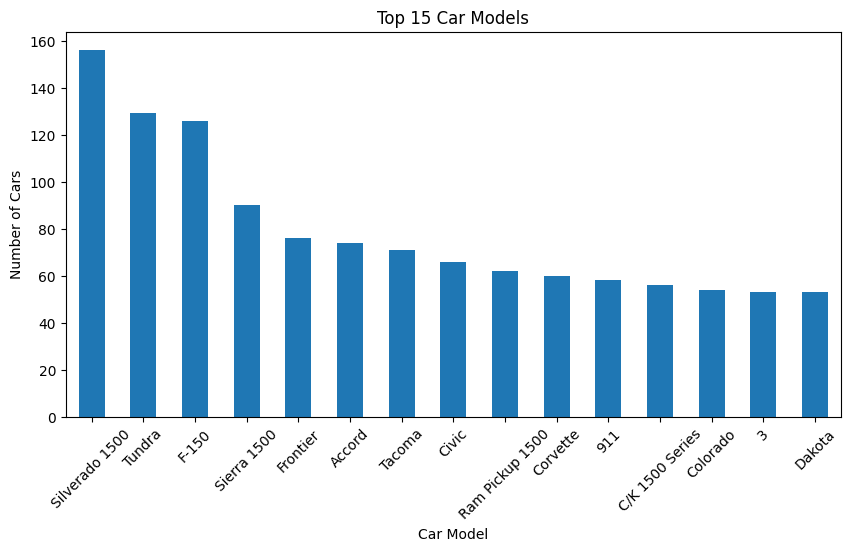

In [34]:
plt.figure(figsize=(10,5))

df["Model"].value_counts().head(15).plot(kind="bar")

plt.xlabel("Car Model")
plt.ylabel("Number of Cars")
plt.title("Top 15 Car Models")

plt.xticks(rotation=45)

plt.show()

In [35]:
with open("my_outputs.txt", "w") as f:
    f.write("Paste your critical text or variable outputs here")


**Define X and y**

Defining Features and Target

The target variable in this project is MSRP, which is the price we want to predict.

All the remaining columns will be used as input features for the model.

In [36]:
X = df.drop("MSRP (Manufacturer's suggested retail Price)", axis=1)

y = df["MSRP (Manufacturer's suggested retail Price)"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (11199, 15)
Shape of y: (11199,)


### Splitting the Data into Training and Testing Sets

I will divide the dataset into training and testing data.

The training data will be used to build the model, while the testing data will be used to check how well the model performs on unseen cars.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8959, 15)
X_test: (2240, 15)
y_train: (8959,)
y_test: (2240,)


### Separating Numerical and Categorical Features

The dataset contains both numerical and categorical columns.

Numerical columns will be scaled, while categorical columns will be converted into numerical form using one-hot encoding.

In [38]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']

Categorical features:
['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']


**Create the ColumnTransformer**

### Preprocessing the Features

Machine learning models need numerical input.

So, I will scale the numerical features and convert the categorical features into numerical values using one-hot encoding.

In [39]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


**Fit and Transform the Training Data**

### Applying the Preprocessing

I will fit the preprocessing steps on the training data and use the same transformation on the test data.

This keeps the test data completely separate during training.

In [40]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print("X_train_trans shape:", X_train_trans.shape)
print("X_test_trans shape:", X_test_trans.shape)

X_train_trans shape: (8959, 1061)
X_test_trans shape: (2240, 1061)


**Feature Selection**

### Selecting the Most Useful Features

After one-hot encoding, the number of features increased to 1,061.

I will select the features that have the strongest relationship with MSRP and use them for the model. bold text

In [41]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=300)

X_train_selected = selector.fit_transform(X_train_trans, y_train)
X_test_selected = selector.transform(X_test_trans)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

X_train_selected shape: (8959, 300)
X_test_selected shape: (2240, 300)


**Choose Regression Models**

### Choosing Regression Models

I will compare a few regression algorithms to see which one predicts car prices better.

KNN and Linear Regression will give us simple models to compare, while Decision Tree and Random Forest can capture more complex relationships in the data.

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

knn = KNeighborsRegressor()
linear = LinearRegression()
tree = DecisionTreeRegressor(random_state=42)
forest = RandomForestRegressor(random_state=42, n_estimators=100)

**Train the Regression Models**

### Training the Regression Models

I will train four different regression models using the selected features.

Later, I will compare their predictions to find which model performs best.

In [43]:
knn.fit(X_train_selected, y_train)

linear.fit(X_train_selected, y_train)

tree.fit(X_train_selected, y_train)

forest.fit(X_train_selected, y_train)

print("All models trained successfully.")

All models trained successfully.


**Make Predictions**

### Making Predictions on the Test Data

The models have been trained using the training data.

Now I will use the test data to predict the MSRP of cars that the models have not seen before.

In [44]:
knn_pred = knn.predict(X_test_selected)

linear_pred = linear.predict(X_test_selected)

tree_pred = tree.predict(X_test_selected)

forest_pred = forest.predict(X_test_selected)

print("Predictions completed successfully.")

Predictions completed successfully.


**Calculate Regression Metrics**

### Evaluating the Regression Models

I will compare the models using MAE, RMSE and R² score.

For MAE and RMSE, lower values are better. For R², a higher value is better.

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "KNN": knn_pred,
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
}

for name, predictions in models.items():
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)

KNN
MAE: 5197.314375
RMSE: 29383.853632171442
R2 Score: 0.8217969280783718
----------------------------------------
Linear Regression
MAE: 5596.318591911861
RMSE: 13484.695205887065
R2 Score: 0.9624698801467398
----------------------------------------
Decision Tree
MAE: 3844.056037898114
RMSE: 13745.591189076056
R2 Score: 0.9610035988870618
----------------------------------------
Random Forest
MAE: 3711.8931628326395
RMSE: 22113.4708889682
R2 Score: 0.8990720365154695
----------------------------------------


**GridSearchCV for KNN**

### Hyperparameter Tuning for KNN

The performance of KNN depends on the number of neighboring points used for prediction.

I will use GridSearchCV to test different values of K and find the best one.

In [46]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2"
)

knn_grid.fit(X_train_selected, y_train)

print("Best K:", knn_grid.best_params_)
print("Best CV R2:", knn_grid.best_score_)

Best K: {'n_neighbors': 3}
Best CV R2: 0.8691350698362845


**Tune the Decision Tree**

### Hyperparameter Tuning for Decision Tree

The Decision Tree performed well in the initial model comparison.

I will use GridSearchCV to find better values for the tree depth and the minimum number of samples required to split a node.

In [47]:
tree_params = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=5,
    scoring="r2"
)

tree_grid.fit(X_train_selected, y_train)

print("Best Parameters:", tree_grid.best_params_)
print("Best CV R2:", tree_grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5}
Best CV R2: 0.8938479801241701


**Tune Linear Regression**

### Hyperparameter Tuning for Linear Regression

Linear Regression already performed very well in the initial comparison.

I will use GridSearchCV to check whether changing the intercept setting improves its performance.

In [48]:
linear_params = {
    "fit_intercept": [True, False]
}

linear_grid = GridSearchCV(
    LinearRegression(),
    linear_params,
    cv=5,
    scoring="r2"
)

linear_grid.fit(X_train_selected, y_train)

print("Best Parameters:", linear_grid.best_params_)
print("Best CV R2:", linear_grid.best_score_)

Best Parameters: {'fit_intercept': True}
Best CV R2: 0.8659405207104609


**Evaluate the Tuned Models**

### Evaluating the Tuned Models

The hyperparameters have been selected using cross-validation.

Now I will test the tuned models on the unseen test data and compare their MAE, RMSE and R² scores.

In [49]:
knn_best = knn_grid.best_estimator_
tree_best = tree_grid.best_estimator_
linear_best = linear_grid.best_estimator_

knn_tuned_pred = knn_best.predict(X_test_selected)
tree_tuned_pred = tree_best.predict(X_test_selected)
linear_tuned_pred = linear_best.predict(X_test_selected)

for name, predictions in {
    "Tuned KNN": knn_tuned_pred,
    "Tuned Decision Tree": tree_tuned_pred,
    "Tuned Linear Regression": linear_tuned_pred
}.items():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)

Tuned KNN
MAE: 4852.080357142857
RMSE: 30115.666101160165
R2 Score: 0.8128100065947752
----------------------------------------
Tuned Decision Tree
MAE: 3882.638866370028
RMSE: 14368.0234979476
R2 Score: 0.9573919418898753
----------------------------------------
Tuned Linear Regression
MAE: 5596.318591911861
RMSE: 13484.695205887065
R2 Score: 0.9624698801467398
----------------------------------------


**Final Model Comparison**

### Final Model Comparison

I will compare the main models using the same test data.

This will help me choose the final model based on MAE, RMSE and R² instead of choosing a model only because it is familiar.

In [50]:
results = {
    "Model": [
        "KNN",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned KNN",
        "Tuned Decision Tree",
        "Tuned Linear Regression"
    ],
    "MAE": [
        mean_absolute_error(y_test, knn_pred),
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, forest_pred),
        mean_absolute_error(y_test, knn_tuned_pred),
        mean_absolute_error(y_test, tree_tuned_pred),
        mean_absolute_error(y_test, linear_tuned_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, knn_pred)),
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred)),
        np.sqrt(mean_squared_error(y_test, forest_pred)),
        np.sqrt(mean_squared_error(y_test, knn_tuned_pred)),
        np.sqrt(mean_squared_error(y_test, tree_tuned_pred)),
        np.sqrt(mean_squared_error(y_test, linear_tuned_pred))
    ],
    "R2 Score": [
        r2_score(y_test, knn_pred),
        r2_score(y_test, linear_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred),
        r2_score(y_test, knn_tuned_pred),
        r2_score(y_test, tree_tuned_pred),
        r2_score(y_test, linear_tuned_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
1,Linear Regression,5596.318592,13484.695206,0.962470
6,Tuned Linear Regression,5596.318592,13484.695206,0.962470
2,Decision Tree,3844.056038,13745.591189,0.961004
5,Tuned Decision Tree,3882.638866,14368.023498,0.957392
3,Random Forest,3711.893163,22113.470889,0.899072
0,KNN,5197.314375,29383.853632,0.821797
4,Tuned KNN,4852.080357,30115.666101,0.812810


**Select the Final Model**

### Selecting the Final Model

After comparing all the models, Linear Regression gave the best overall test performance.

Therefore, I will use Linear Regression as the final model for this project.

In [51]:
final_model = linear_best

print("Final Model: Linear Regression")
print("R2 Score:", r2_score(y_test, final_model.predict(X_test_selected)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_model.predict(X_test_selected))))
print("MAE:", mean_absolute_error(y_test, final_model.predict(X_test_selected)))

Final Model: Linear Regression
R2 Score: 0.9624698801467398
RMSE: 13484.695205887065
MAE: 5596.318591911861


**Create a Complete Prediction Workflow**

### Preparing the Model for Deployment

The final model depends on the preprocessing and feature selection steps used during training.

I will save these components so that new car details can go through the same process before making a prediction.

In [52]:
import joblib

joblib.dump(preprocessor, "car_price_preprocessor.pkl")
joblib.dump(selector, "car_price_selector.pkl")
joblib.dump(final_model, "car_price_model.pkl")

print("Model files saved successfully.")

Model files saved successfully.


**Create a Sample Car**

### Testing the Model with a Sample Car

I will create one sample car using the same features that were used during model training.

The sample will go through the same preprocessing and feature selection steps before predicting its MSRP.

In [53]:
sample_car = pd.DataFrame({
    "Make": ["Toyota"],
    "Model": ["Camry"],
    "Year": [2015],
    "Engine Fuel Type": ["regular unleaded"],
    "Engine HP": [178],
    "Engine Cylinders": [4],
    "Transmission Type": ["AUTOMATIC"],
    "Driven_Wheels": ["front wheel drive"],
    "Number of Doors": [4],
    "Market Category": ["Sedan"],
    "Vehicle Size": ["Midsize"],
    "Vehicle Style": ["Sedan"],
    "highway MPG": [35],
    "city mpg": [25],
    "Popularity": [2031]
})

sample_car

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity
0,Toyota,Camry,2015,regular unleaded,178,4,AUTOMATIC,front wheel drive,4,Sedan,Midsize,Sedan,35,25,2031


**Make the Sample Prediction**

### Predicting the MSRP of the Sample Car

The sample car will first be transformed using the fitted preprocessor.

Then the selected features will be passed to the final Linear Regression model to predict the MSRP.

In [54]:
sample_trans = preprocessor.transform(sample_car)

sample_selected = selector.transform(sample_trans)

sample_prediction = final_model.predict(sample_selected)

print("Predicted MSRP:", sample_prediction[0])

Predicted MSRP: 25941.857184501874


**Actual vs Predicted MSRP**

### Actual vs Predicted Prices

I will compare the actual MSRP values with the prices predicted by the final model.

A good model should have predictions that are close to the actual prices.

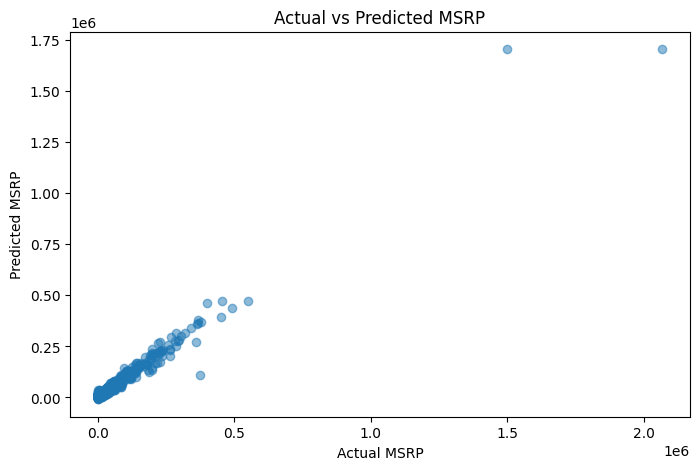

In [55]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, linear_tuned_pred, alpha=0.5)

plt.xlabel("Actual MSRP")
plt.ylabel("Predicted MSRP")
plt.title("Actual vs Predicted MSRP")

plt.show()

**Add Perfect Prediction Line**

### Comparing Actual and Predicted MSRP

The diagonal line represents perfect predictions.

If the predicted price is exactly equal to the actual price, the point will lie on this line.

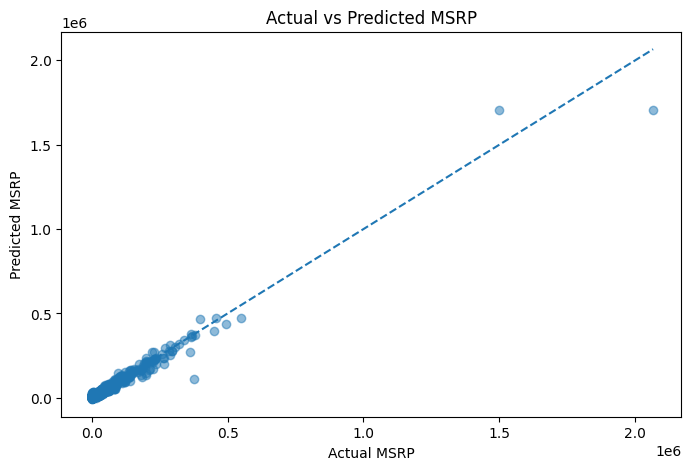

In [56]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, linear_tuned_pred, alpha=0.5)

min_value = min(y_test.min(), linear_tuned_pred.min())
max_value = max(y_test.max(), linear_tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MSRP")
plt.ylabel("Predicted MSRP")
plt.title("Actual vs Predicted MSRP")

plt.show()

**Create the Streamlit App**

### Creating the Streamlit Application

I will create a simple Streamlit application for the car price prediction system.

The user can enter the car specifications, and the trained model will predict the MSRP.

In [57]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 105.1 MB/s eta 0:00:00


In [58]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Car Price Prediction System",
    page_icon="🚗",
    layout="wide"
)


# --------------------------------------------------
# Load Model Files
# --------------------------------------------------

@st.cache_resource
def load_model_files():
    model = joblib.load("car_price_model.pkl")
    preprocessor = joblib.load("car_price_preprocessor.pkl")
    selector = joblib.load("car_price_selector.pkl")

    return model, preprocessor, selector


@st.cache_data
def load_dataset():
    df = pd.read_csv("car_MSRP.csv")

    # Remove duplicate records
    df = df.drop_duplicates()

    # Handle missing numerical values
    df["Engine HP"] = df["Engine HP"].fillna(
        df["Engine HP"].median()
    )

    df["Engine Cylinders"] = df["Engine Cylinders"].fillna(
        df["Engine Cylinders"].median()
    )

    df["Number of Doors"] = df["Number of Doors"].fillna(
        df["Number of Doors"].median()
    )

    # Handle missing categorical values
    df["Engine Fuel Type"] = df["Engine Fuel Type"].fillna(
        df["Engine Fuel Type"].mode()[0]
    )

    df["Market Category"] = df["Market Category"].fillna("Unknown")

    return df


model, preprocessor, selector = load_model_files()
df = load_dataset()


# --------------------------------------------------
# Application Title
# --------------------------------------------------

st.title("🚗 Car Price Prediction System")

st.write(
    "Enter the car specifications below to estimate "
    "the Manufacturer's Suggested Retail Price (MSRP)."
)


# --------------------------------------------------
# Basic Car Information
# --------------------------------------------------

st.header("1. Basic Car Information")

col1, col2, col3 = st.columns(3)

with col1:
    make = st.selectbox(
        "Make",
        sorted(df["Make"].unique())
    )

with col2:
    model_name = st.selectbox(
        "Model",
        sorted(df["Model"].unique())
    )

with col3:
    year = st.number_input(
        "Year",
        min_value=int(df["Year"].min()),
        max_value=int(df["Year"].max()),
        value=2015,
        step=1
    )


# --------------------------------------------------
# Engine Information
# --------------------------------------------------

st.header("2. Engine Information")

col1, col2, col3 = st.columns(3)

with col1:
    engine_fuel_type = st.selectbox(
        "Engine Fuel Type",
        sorted(df["Engine Fuel Type"].unique())
    )

with col2:
    engine_hp = st.number_input(
        "Engine HP",
        min_value=0.0,
        max_value=1500.0,
        value=178.0,
        step=1.0
    )

with col3:
    engine_cylinders = st.number_input(
        "Engine Cylinders",
        min_value=0.0,
        max_value=20.0,
        value=4.0,
        step=1.0
    )


# --------------------------------------------------
# Transmission and Driving Information
# --------------------------------------------------

st.header("3. Transmission and Driving Information")

col1, col2, col3 = st.columns(3)

with col1:
    transmission_type = st.selectbox(
        "Transmission Type",
        sorted(df["Transmission Type"].unique())
    )

with col2:
    driven_wheels = st.selectbox(
        "Driven Wheels",
        sorted(df["Driven_Wheels"].unique())
    )

with col3:
    number_of_doors = st.number_input(
        "Number of Doors",
        min_value=2.0,
        max_value=4.0,
        value=4.0,
        step=1.0
    )


# --------------------------------------------------
# Vehicle Information
# --------------------------------------------------

st.header("4. Vehicle Information")

col1, col2, col3 = st.columns(3)

with col1:
    market_category = st.selectbox(
        "Market Category",
        sorted(df["Market Category"].unique())
    )

with col2:
    vehicle_size = st.selectbox(
        "Vehicle Size",
        sorted(df["Vehicle Size"].unique())
    )

with col3:
    vehicle_style = st.selectbox(
        "Vehicle Style",
        sorted(df["Vehicle Style"].unique())
    )


# --------------------------------------------------
# Mileage and Popularity
# --------------------------------------------------

st.header("5. Mileage and Popularity")

col1, col2, col3 = st.columns(3)

with col1:
    highway_mpg = st.number_input(
        "Highway MPG",
        min_value=0,
        max_value=400,
        value=35,
        step=1
    )

with col2:
    city_mpg = st.number_input(
        "City MPG",
        min_value=0,
        max_value=200,
        value=25,
        step=1
    )

with col3:
    popularity = st.number_input(
        "Popularity",
        min_value=0,
        max_value=10000,
        value=2031,
        step=1
    )


# --------------------------------------------------
# Prediction Section
# --------------------------------------------------

st.divider()

st.subheader("Get Estimated MSRP")

predict_button = st.button(
    "Predict MSRP",
    type="primary"
)


# --------------------------------------------------
# Prediction Logic
# --------------------------------------------------

if predict_button:

    # Validate input values
    if engine_hp <= 0:
        st.error("Please enter a valid Engine HP greater than 0.")

    elif engine_cylinders <= 0:
        st.error("Please enter a valid number of engine cylinders.")

    elif highway_mpg <= 0 or city_mpg <= 0:
        st.error("Highway MPG and City MPG must be greater than 0.")

    elif popularity < 0:
        st.error("Popularity cannot be negative.")

    else:

        # Create input DataFrame
        input_data = pd.DataFrame({
            "Make": [make],
            "Model": [model_name],
            "Year": [year],
            "Engine Fuel Type": [engine_fuel_type],
            "Engine HP": [engine_hp],
            "Engine Cylinders": [engine_cylinders],
            "Transmission Type": [transmission_type],
            "Driven_Wheels": [driven_wheels],
            "Number of Doors": [number_of_doors],
            "Market Category": [market_category],
            "Vehicle Size": [vehicle_size],
            "Vehicle Style": [vehicle_style],
            "highway MPG": [highway_mpg],
            "city mpg": [city_mpg],
            "Popularity": [popularity]
        })

        try:
            # Apply preprocessing
            input_transformed = preprocessor.transform(input_data)

            # Apply feature selection
            input_selected = selector.transform(input_transformed)

            # Generate prediction
            prediction = model.predict(input_selected)

            predicted_price = prediction[0]

            # Display result
            st.success(
                f"Estimated MSRP: ${predicted_price:,.2f}"
            )

            st.info(
                "The prediction was generated using the trained "
                "Linear Regression model."
            )

        except Exception as error:
            st.error(
                "An error occurred while generating the prediction."
            )

            st.write("Please check whether all input values are valid.")

Writing app.py


In [59]:
import os

print("app.py ->", os.path.exists("app.py"))
print("car_MSRP.csv ->", os.path.exists("car_MSRP.csv"))
print("car_price_model.pkl ->", os.path.exists("car_price_model.pkl"))
print("car_price_preprocessor.pkl ->", os.path.exists("car_price_preprocessor.pkl"))
print("car_price_selector.pkl ->", os.path.exists("car_price_selector.pkl"))

app.py -> True
car_MSRP.csv -> True
car_price_model.pkl -> True
car_price_preprocessor.pkl -> True
car_price_selector.pkl -> True


In [60]:
!streamlit run app.py --server.port 8501 > streamlit_log.txt 2>&1 &

In [61]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 7s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
!lt --port 8501

your url is: https://huge-vans-accept.loca.lt
